In [1]:

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler , StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


2025-05-19 23:31:06.171268: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-19 23:31:06.183113: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747672266.199996   38200 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747672266.204456   38200 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1747672266.216450   38200 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
# Constants
RANDOM_SEED = 42
NUM_CLASSES = 5

In [3]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


# Specify each path

In [4]:
train_dataset = 'model/keypoint_classifier/gesture_3/cleaned_keypoint.csv'
test_dataset = 'model/keypoint_classifier/test.csv'
model_save_path = 'model/keypoint_classifier/gesture_3/keypoint_classifier.keras'
tflite_save_path = 'model/keypoint_classifier/gesture_3/keypoint_classifier.tflite'

# Dataset reading

In [5]:
# Load train data
X_train = np.loadtxt(train_dataset, delimiter=',', dtype='float32', usecols=range(1, 43), skiprows=1)
y_train = np.loadtxt(train_dataset, delimiter=',', dtype='int32', usecols=(0), skiprows=1)
# # Load test data
# X_test = np.loadtxt(test_dataset, delimiter=',', dtype='float32', usecols=range(1, 43))
# y_test = np.loadtxt(test_dataset, delimiter=',', dtype='int32', usecols=(0))

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train, test_size=0.1, random_state=RANDOM_SEED
)

In [7]:
print(f'trans set size:{len(X_train)}, test set size:{len(X_test)}')

trans set size:66222, test set size:7359


In [8]:
# Print out datasets as numpy array
print("First 5 rows of X_dataset:")
print(X_train[:5])

print("First 5 values of y_dataset:")
print(y_train[:5])

First 5 rows of X_dataset:
[[0.14261168 0.64524424 0.12542956 0.5994832  0.12876254 0.5654321
  0.15126051 0.5368171  0.21565495 0.5265589  0.14072847 0.60880196
  0.1764706  0.5879265  0.20142603 0.59949625 0.229097   0.6413793
  0.17198582 0.6104513  0.24064171 0.5888325  0.27210885 0.5347044
  0.28250402 0.5612472  0.2580645  0.6130536  0.29836065 0.55990785
  0.3032929  0.5244755  0.29508197 0.5105882  0.3164557  0.61275625
  0.3443396  0.56570154 0.38322368 0.5054466  0.42700157 0.484375  ]
 [0.661512   0.84061694 0.6426117  0.80878556 0.6086956  0.7802469
  0.58655465 0.80285037 0.58785945 0.84757507 0.7168874  0.8190709
  0.7326203  0.8057743  0.7254902  0.71284634 0.71404684 0.65977013
  0.7925532  0.8622328  0.8163993  0.8654822  0.79591835 0.7377892
  0.7704655  0.66592425 0.82173175 0.9137529  0.7163935  0.92626727
  0.6689775  0.8811189  0.6575592  0.84       0.7958861  0.9498861
  0.6839623  0.95100224 0.63980263 0.90631807 0.6122449  0.8535156 ]
 [0.33505154 0.41388175 0.

In [9]:
# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train), y=y_train
)
class_weights_dict = dict(enumerate(class_weights))

# Model building

In [10]:
# Define improved model
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((42, )),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

I0000 00:00:1747672281.034327   38200 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2791 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


In [11]:
model.summary()# tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 42)             │           168 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         5,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,173 (63.18 KB)

 Trainable params: 16,089 (62.85 KB)

 Non-trainable params: 84 (336.00 B)

In [12]:
# Callbacks
cp_callback = tf.keras.callbacks.ModelCheckpoint(model_save_path, verbose=1, save_weights_only=False)
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [13]:
# Compile model
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model training

In [14]:
# Train model
history = model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    class_weight=class_weights_dict,
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000


I0000 00:00:1747492521.580588    8151 service.cc:152] XLA service 0x7826b8005b40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747492521.580610    8151 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce GTX 1650, Compute Capability 7.5
2025-05-17 21:35:21.633023: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1747492521.937415    8151 cuda_dnn.cc:529] Loaded cuDNN version 90300


 59/518 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2199 - loss: 1.6415

I0000 00:00:1747492524.415102    8151 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3494 - loss: 1.4188
Epoch 1: saving model to model/keypoint_classifier/gesture_3/keypoint_classifier.keras
518/518 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.3496 - loss: 1.4184 - val_accuracy: 0.7244 - val_loss: 0.7917
Epoch 2/1000
504/518 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6844 - loss: 0.7425
Epoch 2: saving model to model/keypoint_classifier/gesture_3/keypoint_classifier.keras
518/518 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6856 - loss: 0.7399 - val_accuracy: 0.8803 - val_loss: 0.4038
Epoch 3/1000
514/518 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8389 - loss: 0.4246
Epoch 3: saving model to model/keypoint_classifier/gesture_3/keypoint_classifier.keras
518/518 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8391 - loss: 0.4242 - val_accuracy: 0.9312 - val_loss: 0.2300
Epoch 4/1000
508/518 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9032 - loss: 0.2807
Epoch 4: saving model to model/keypoint_classif

In [32]:
def plot_training_history(history):
    # Create a figure with 2 subplots (1 row, 2 columns)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot training & validation accuracy
    ax1.plot(history.history['accuracy'])
    ax1.plot(history.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='lower right')
    ax1.grid(True)
    
    # Plot training & validation loss
    ax2.plot(history.history['loss'])
    ax2.plot(history.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper right')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

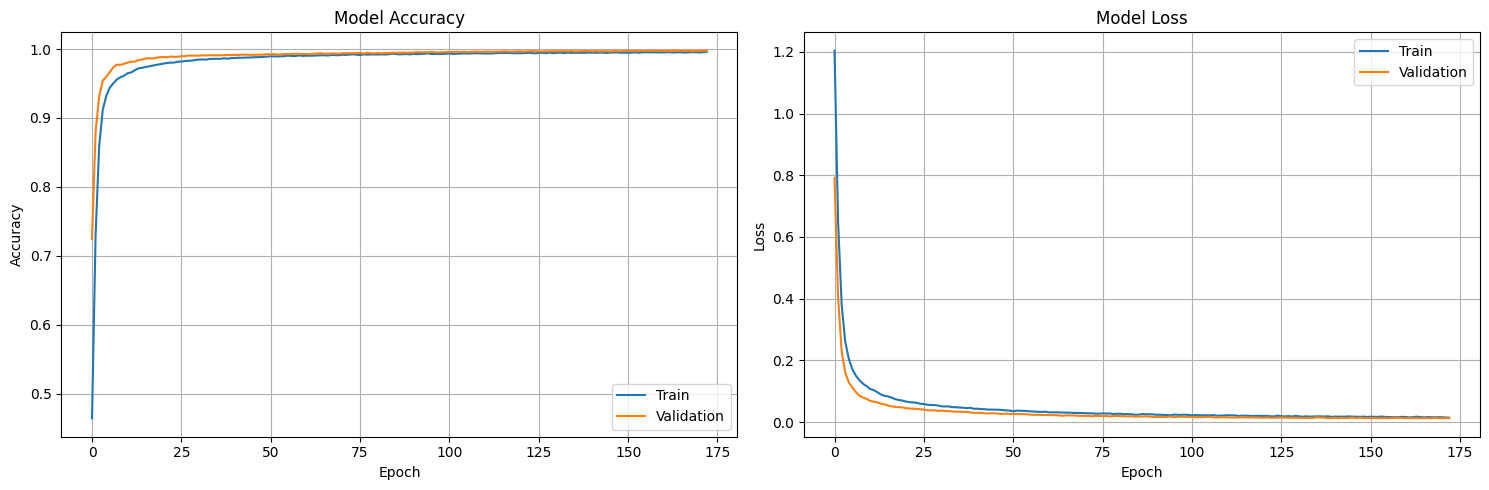

In [33]:
plot_training_history(history)

In [34]:
# You can also plot additional metrics if your model has them
# For example, if you're using metrics like AUC, precision, recall, etc.:
def plot_additional_metrics(history):
    # Identify available metrics (excluding 'loss' and 'accuracy' which we already plotted)
    metrics = [m for m in history.history.keys() 
              if not m.startswith('val_') and m not in ['loss', 'accuracy']]
    
    # Create plots for each additional metric
    for metric in metrics:
        plt.figure(figsize=(10, 6))
        plt.plot(history.history[metric])
        
        # Check if we have validation data for this metric
        val_metric = f'val_{metric}'
        if val_metric in history.history:
            plt.plot(history.history[val_metric])
            plt.legend(['Train', 'Validation'], loc='best')
        else:
            plt.legend(['Train'], loc='best')
            
        plt.title(f'Model {metric.capitalize()}')
        plt.ylabel(metric.capitalize())
        plt.xlabel('Epoch')
        plt.grid(True)
        plt.show()

In [35]:
plot_additional_metrics(history)

In [36]:
# To visualize early stopping, you can see where training stopped
def plot_with_early_stopping_point(history):
    epochs_trained = len(history.history['loss'])
    plt.figure(figsize=(10, 6))
    
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    
    # Add a vertical line at the early stopping point if early stopping occurred
    if epochs_trained < 1000:  # If we didn't reach max epochs
        plt.axvline(x=epochs_trained-1, color='r', linestyle='--', 
                   label=f'Early Stopping (epoch {epochs_trained})')
    
    plt.title('Training & Validation Loss with Early Stopping Point')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

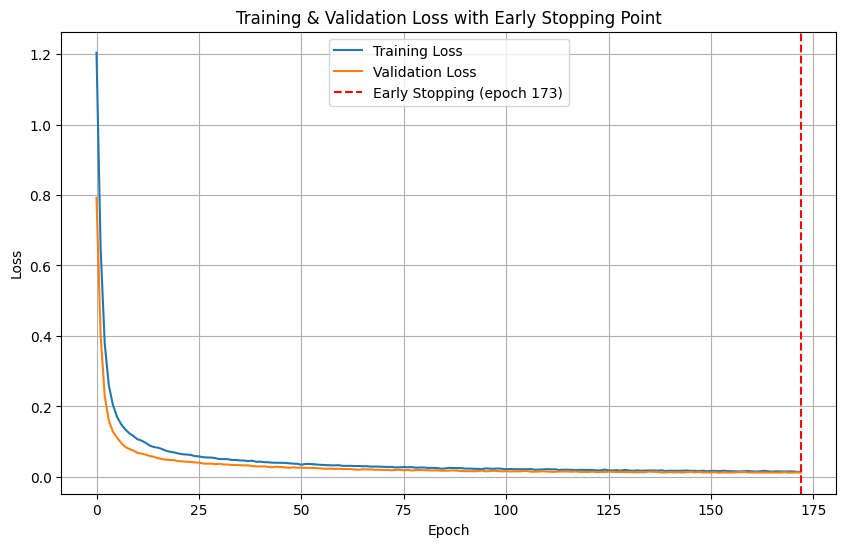

In [37]:
plot_with_early_stopping_point(history)

In [38]:
# Model evaluation
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9980 - loss: 0.0106


In [39]:
# Loading the saved model
model = tf.keras.models.load_model(model_save_path)

In [40]:
# Inference test
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step
[9.9999654e-01 8.7960836e-07 4.8277730e-07 1.3025120e-06 8.6409773e-07]
0


# Confusion matrix

230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


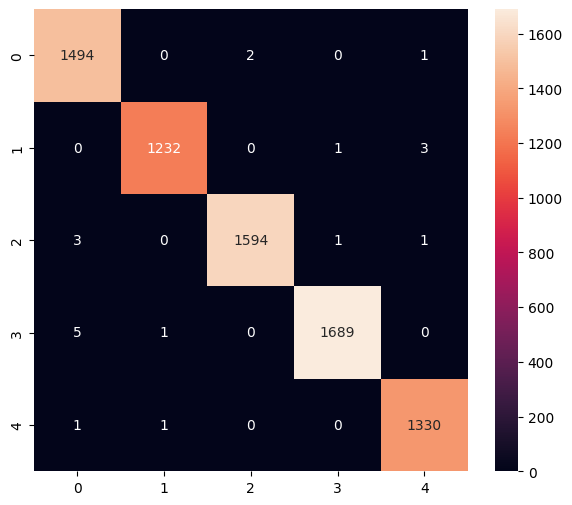

Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1497
           1       1.00      1.00      1.00      1236
           2       1.00      1.00      1.00      1599
           3       1.00      1.00      1.00      1695
           4       1.00      1.00      1.00      1332

    accuracy                           1.00      7359
   macro avg       1.00      1.00      1.00      7359
weighted avg       1.00      1.00      1.00      7359



In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Convert to model for Tensorflow-Lite

In [42]:
# Save as a model dedicated to inference
model.save(model_save_path, include_optimizer=False)

In [43]:
# Transform model (quantization)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: /tmp/tmpjpvmyauv/assets


INFO:tensorflow:Assets written to: /tmp/tmpjpvmyauv/assets


Saved artifact at '/tmp/tmpjpvmyauv'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  132111207226576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132111207226768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132111207225424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132111207224080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132111207224272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132111207226192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132111207226384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132111207230416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132111207220048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132111207231568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132111207230992: TensorS

W0000 00:00:1747492848.067935    6699 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1747492848.067967    6699 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2025-05-17 21:40:48.068181: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpjpvmyauv
2025-05-17 21:40:48.068837: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-05-17 21:40:48.068844: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpjpvmyauv
2025-05-17 21:40:48.075101: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-05-17 21:40:48.124096: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpjpvmyauv
2025-05-17 21:40:48.143462: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 75285 microseconds.


22672

# Inference test

In [44]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

In [45]:
# Get I / O tensor
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [46]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [47]:
%%time
# Inference implementation
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: user 492 μs, sys: 41 μs, total: 533 μs
Wall time: 437 μs


In [48]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[9.9999559e-01 1.0417831e-06 6.9723973e-07 1.6322911e-06 1.0868540e-06]
0
